In [2]:
import sys
sys.path.append("../")

from src.data_preprocessing import clean_data
from src.feature_engineering import create_features

In [3]:
import pandas as pd

df = pd.read_csv("../data/uber.csv")

In [4]:
df = clean_data(df)
df = create_features(df)

In [5]:
X = df[['distance_km', 'hour', 'day_of_week', 'month', 'passenger_count', 'is_peak']]
y = df['fare_amount']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
import pickle

with open("../models/model.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded!")

D:\Anaconda\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model loaded!


D:\Anaconda\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [8]:
preds = model.predict(X_test)

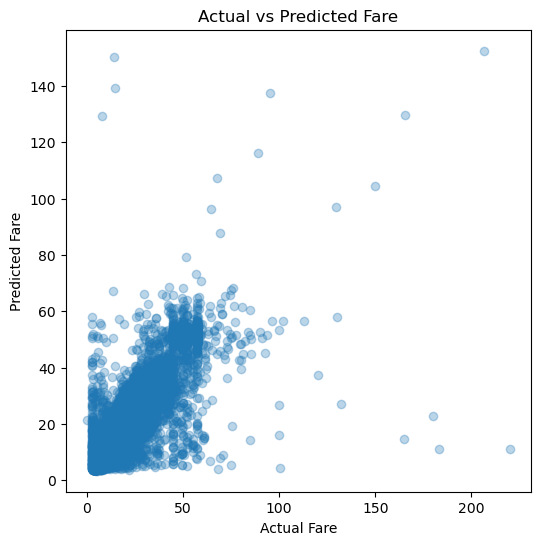

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.3)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.show()

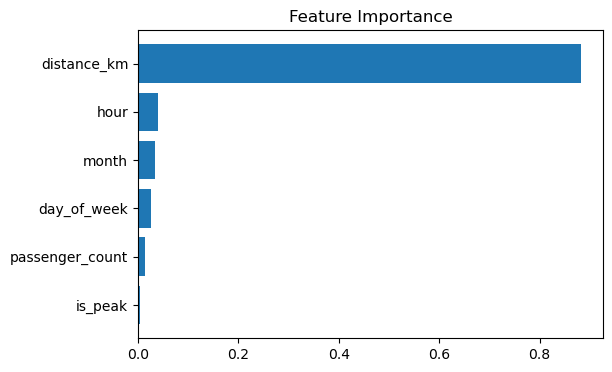

In [10]:
import numpy as np

importances = model.feature_importances_
features = X.columns

indices = np.argsort(importances)

plt.figure(figsize=(6,4))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.title("Feature Importance")
plt.show()

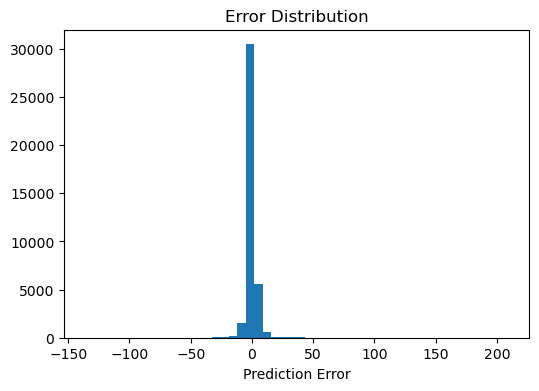

In [11]:
errors = y_test - preds

plt.figure(figsize=(6,4))
plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.show()